# RF-DETR Deformable Attention Evidence Map (v3)

Architecture-aware XAI for RF-DETR. Rather than running only `model.predict()`, this notebook
calls the raw decoder forward and instruments every `MSDeformAttn` module to record
`sampling_locations` and `attention_weights`. Those tensors are mapped back to image
coordinates for the selected detection query and visualised as a decoder-attention evidence map.

**Method name (thesis):** *RF-DETR Deformable Attention Evidence Map*

**Why below `model.predict()`:**  
`predict()` hides the raw decoder queries. The useful XAI signal is `MSDeformAttn.sampling_locations`
and `MSDeformAttn.attention_weights` produced during the decoder cross-attention. We monkey-patch
each `MSDeformAttn` forward before calling the inner model and restore it afterwards.

**Which query to explain:**  
Do **not** pick a query from raw `topk` logits alone — those slots are often empty or low-confidence.  
Run `model.predict(image, threshold=…)` first, then **match each returned box to the best object query** by **IoU** against all raw `pred_boxes` (cxcywh → xyxy, scaled to image pixels, same geometry as the post-processor).  
Explain only queries whose match passes `matched_iou >= MIN_MATCH_IOU` (default 0.5).  
Matching prefers **class-consistent** queries (argmax class on raw `pred_logits.sigmoid` equals the `predict()` class) among highest-IoU candidates; if that fails the IoU threshold, the notebook **falls back to IoU-only** and prints a warning.

We save a **sparse** attention map (integer binning of sampling locations) and a **Gaussian-splatted** map (`GAUSSIAN_SPLAT_SIGMA`) for figures; splatting is visualization-only.

The flattened `topk` mapping (`query_id = topk_index // num_classes`) still mirrors RF-DETR’s post-processor and is printed **for debug only** — figures use **predict + (class-aware) IoU** selection.

In [12]:
from pathlib import Path
import os
import random
import sys
import site

def find_repo_root(marker='pyproject.toml', max_depth=10):
    """Search upward from current directory for repo marker file."""
    current = Path.cwd().resolve()
    for _ in range(max_depth):
        if (current / marker).exists():
            return current
        current = current.parent
    return None

def prefer_venv_site_packages():
    """Keep venv site-packages before cluster/global package paths."""
    venv_prefix = str(Path(sys.prefix).resolve())
    venv_sites = [p for p in site.getsitepackages() if p.startswith(venv_prefix)]
    cleaned = [p for p in sys.path if not (p.startswith('/net/software/') and 'site-packages' in p)]
    for p in reversed(venv_sites):
        if p in cleaned:
            cleaned.remove(p)
        cleaned.insert(0, p)
    sys.path[:] = cleaned

    cached = sys.modules.get('regex')
    cached_path = getattr(cached, '__file__', '') if cached is not None else ''
    if cached_path.startswith('/net/software/'):
        for name in list(sys.modules.keys()):
            if name == 'regex' or name.startswith('regex.'):
                del sys.modules[name]

REPO_ROOT = find_repo_root()
if REPO_ROOT is None:
    REPO_ROOT = Path('/net/tscratch/people/plgbmruszaj/dermatoscopy_ai')

RFD_XAI_ROOT = REPO_ROOT / 'dermato_ai' / 'rfdetr-xai'
os.chdir(RFD_XAI_ROOT)
sys.path.insert(0, str(RFD_XAI_ROOT / 'src'))
sys.path.insert(0, str(REPO_ROOT))
prefer_venv_site_packages()

from dermato_ai.coco.dataset_manager import COCODatasetManager

DATA_ZIP_DIR = REPO_ROOT / 'data' / 'coco_images_zip'
manager = COCODatasetManager.from_archive(
    directory=DATA_ZIP_DIR,
    archive_pattern='*.zip',
)
dataset_dir = Path(manager.json_path).parent
dedup_coco_json = dataset_dir / 'result_dedup_for_attention_map.json'
manager.save(str(dedup_coco_json))
COCO_JSON   = str(dedup_coco_json)
IMAGES_DIR  = str(dataset_dir / 'images')

CHECKPOINT   = '/net/tscratch/people/plgbmruszaj/rfdetr_all_data_results_yellow_large_20260507_150528/rfdetr_large_best_2573873/checkpoints/checkpoint_best_ema.pth'
OUTPUT_DIR   = str((RFD_XAI_ROOT / 'wyniki' / 'rfdetr_xai_v3_attention').resolve())
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# ---------- tuneable parameters ----------
MODEL_SIZE       = 'large'
THRESHOLD        = 0.5     # dla publikacji ustaw jak w pracy; obniż jeśli brak detekcji w losowej próbce
RANDOM_SEED      = 42
N_RANDOM_DRAW    = 10    # losujemy tyle indeksów z COCO; dalej: pierwsze zdjęcie z detekcją (główna ścieżka) oraz batch tylko dla zdjęć z detekcjami
EXPLAIN_DET_INDEX = 0     # która detekcja z predict() (0 = pierwsza)
MIN_MATCH_IOU    = 0.5   # require IoU(predict_box, raw_query_box) >= this for XAI
LAST_N_LAYERS    = 3     # aggregate only the last N captured decoder layers
GAUSSIAN_SPLAT_SIGMA = 12.0  # splat each sampling point into a 2D Gaussian (viz only; saved separately from sparse)
POST_SPLAT_BLUR = 0      # optional odd cv2.GaussianBlur on splatted map (0 = off)
OVERLAY_ALPHA    = 0.45  # heatmap overlay transparency
SAVE_ALL_DET_HEATMAPS = True  # after single-image run, export overlay per predict() detection

_n_img = len(manager.data['images'])
random.seed(RANDOM_SEED)
RANDOM_IMAGE_INDICES = random.sample(range(_n_img), min(N_RANDOM_DRAW, _n_img))
IMAGE_PATH = None  # ustawiane po załadowaniu modelu: pierwsze z losowej dziesiątki z predict() > 0

print('\u2713 Python executable:', sys.executable)
print('\u2713 COCO JSON:', COCO_JSON)
print('\u2713 Images dir:', IMAGES_DIR)
print(f'\u2713 Losowe indeksy (N={len(RANDOM_IMAGE_INDICES)}):', RANDOM_IMAGE_INDICES)
print('  IMAGE_PATH = pierwsze z tej listy, dla którego model.predict() zwraca detekcje (komórka z modelem).')
print('\u2713 Checkpoint:', CHECKPOINT)
print('\u2713 Output dir:', OUTPUT_DIR)

INFO: Found newest archive: project-5-at-2026-05-07-11-56-9b7fa76c.zip
INFO: Unpacking project-5-at-2026-05-07-11-56-9b7fa76c.zip to /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted
INFO: Extraction complete
INFO: Found result.json at: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted/result.json
INFO: Loading COCO dataset from /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted/result.json
INFO: Loaded 314 images, 1299 annotations
INFO: Collapsed duplicate image passes: removed 97 image entries and 0 annotations
INFO: Valid COCO structure: 217 images, 1299 annotations, 10 categories
INFO: Fixed 217 image paths
INFO: Saved dataset to /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted/result_dedup_for_attention_map.json


✓ Python executable: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/.venv/bin/python
✓ COCO JSON: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted/result_dedup_for_attention_map.json
✓ Images dir: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted/images
✓ Losowe indeksy (N=10): [163, 28, 6, 189, 70, 62, 57, 35, 188, 26]
  IMAGE_PATH = pierwsze z tej listy, dla którego model.predict() zwraca detekcje (komórka z modelem).
✓ Checkpoint: /net/tscratch/people/plgbmruszaj/rfdetr_all_data_results_yellow_large_20260507_150528/rfdetr_large_best_2573873/checkpoints/checkpoint_best_ema.pth
✓ Output dir: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/dermato_ai/rfdetr-xai/wyniki/rfdetr_xai_v3_attention


## Recorder and Utilities

The `DeformableAttentionRecorder` context manager monkey-patches every `MSDeformAttn` in the
model, accumulates `(sampling_locations, attention_weights, spatial_shapes)` per layer call,
and restores the original forward on exit.

The patch replicates the exact forward logic from the installed
`rfdetr.models.ops.modules.ms_deform_attn.MSDeformAttn` so the outputs are identical.

In [13]:
import json
from dataclasses import dataclass

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torchvision.ops import box_iou
from PIL import Image, ImageDraw

from rfdetr.models.ops.functions import ms_deform_attn_core_pytorch
from rfdetr.models.ops.modules.ms_deform_attn import MSDeformAttn


@dataclass
class AttentionRecord:
    """One captured MSDeformAttn call: sampling points + weights per query."""
    name: str
    sampling_locations: torch.Tensor  # [B, Q, heads, levels, points, 2]  (CPU)
    attention_weights:  torch.Tensor  # [B, Q, heads, levels, points]      (CPU)
    spatial_shapes:     torch.Tensor  # [levels, 2]                        (CPU)


class DeformableAttentionRecorder:
    """Context manager: patches every MSDeformAttn in `model` and records attention data."""

    def __init__(self, model: torch.nn.Module):
        self.model = model
        self.records: list[AttentionRecord] = []
        self._original_forwards: list[tuple] = []

    def __enter__(self):
        for name, module in self.model.named_modules():
            if isinstance(module, MSDeformAttn):
                self._patch(name, module)
        return self

    def __exit__(self, *_):
        for module, orig in self._original_forwards:
            module.forward = orig
        self._original_forwards.clear()

    def _patch(self, name: str, module: MSDeformAttn):
        orig = module.forward
        self._original_forwards.append((module, orig))
        recorder = self  # capture self for the closure

        def _forward(
            query,
            reference_points,
            input_flatten,
            input_spatial_shapes,
            input_level_start_index,
            input_padding_mask=None,
            input_spatial_shapes_hw=None,
        ):
            B, Lq, _ = query.shape
            B, Li, _ = input_flatten.shape

            value = module.value_proj(input_flatten)
            if input_padding_mask is not None:
                value = value.masked_fill(input_padding_mask[..., None], 0.0)

            sampling_offsets = module.sampling_offsets(query).view(
                B, Lq, module.n_heads, module.n_levels, module.n_points, 2
            )
            attn_w = module.attention_weights(query).view(
                B, Lq, module.n_heads, module.n_levels * module.n_points
            )

            if reference_points.shape[-1] == 2:
                offset_norm = torch.stack(
                    [input_spatial_shapes[..., 1], input_spatial_shapes[..., 0]], dim=-1
                )
                sampling_locations = (
                    reference_points[:, :, None, :, None, :]
                    + sampling_offsets / offset_norm[None, None, None, :, None, :]
                )
            elif reference_points.shape[-1] == 4:
                sampling_locations = (
                    reference_points[:, :, None, :, None, :2]
                    + sampling_offsets / module.n_points
                    * reference_points[:, :, None, :, None, 2:] * 0.5
                )
            else:
                raise ValueError(f'reference_points last dim must be 2 or 4, got {reference_points.shape[-1]}')

            attn_w = F.softmax(attn_w, dim=-1)

            # --- record ---
            recorder.records.append(AttentionRecord(
                name=name,
                sampling_locations=sampling_locations.detach().cpu(),
                attention_weights=attn_w.detach().cpu().view(
                    B, Lq, module.n_heads, module.n_levels, module.n_points
                ),
                spatial_shapes=input_spatial_shapes.detach().cpu(),
            ))

            value = value.transpose(1, 2).contiguous().view(
                B, module.n_heads, module.d_model // module.n_heads, Li
            )
            try:
                out = ms_deform_attn_core_pytorch(
                    value, input_spatial_shapes, sampling_locations, attn_w,
                    value_spatial_shapes_hw=input_spatial_shapes_hw,
                )
            except TypeError:
                out = ms_deform_attn_core_pytorch(
                    value, input_spatial_shapes, sampling_locations, attn_w
                )
            return module.output_proj(out)

        module.forward = _forward


# ── preprocessing ────────────────────────────────────────────────────────────

def preprocess_for_rfdetr(rf_model, pil_image: Image.Image):
    """Return (source_rgb_array, batch_tensor, target_sizes) matching rfdetr internals."""
    source     = np.array(pil_image.convert('RGB'))
    h, w       = source.shape[:2]
    resolution = int(rf_model.model.resolution)
    device     = torch.device(str(rf_model.model.device))

    t = TF.to_tensor(pil_image.convert('RGB'))
    t = TF.resize(t, [resolution, resolution])
    t = TF.normalize(t, rf_model.means, rf_model.stds)

    batch        = t.unsqueeze(0).to(device)
    target_sizes = torch.tensor([[h, w]], device=device)
    return source, batch, target_sizes


# ── postprocess matching RF-DETR's own postprocessor ─────────────────────────

def _box_cxcywh_to_xyxy(boxes: torch.Tensor) -> torch.Tensor:
    xc, yc, bw, bh = boxes.unbind(-1)
    return torch.stack([
        xc - 0.5 * bw.clamp(min=0.0),
        yc - 0.5 * bh.clamp(min=0.0),
        xc + 0.5 * bw.clamp(min=0.0),
        yc + 0.5 * bh.clamp(min=0.0),
    ], dim=-1)


def postprocess_raw_outputs(outputs: dict, target_sizes: torch.Tensor, topk: int = 300):
    """Reproduces RF-DETR post-processor; also returns query_ids for XAI."""
    logits = outputs['pred_logits']   # [B, Q, C]
    boxes  = outputs['pred_boxes']    # [B, Q, 4]  cxcywh, normalised
    num_cls = logits.shape[-1]

    prob       = logits.sigmoid()
    flat       = prob.flatten(1)
    k          = min(topk, flat.shape[1])
    scores, ix = torch.topk(flat, k=k, dim=1)

    query_ids = ix // num_cls
    class_ids = ix % num_cls

    boxes_xyxy = _box_cxcywh_to_xyxy(boxes)
    gathered   = torch.gather(boxes_xyxy, 1, query_ids.unsqueeze(-1).expand(-1, -1, 4))

    img_h, img_w = target_sizes.unbind(1)
    scale = torch.stack([img_w, img_h, img_w, img_h], dim=1)
    gathered = gathered * scale[:, None, :]

    return {'scores': scores, 'labels': class_ids, 'boxes': gathered, 'query_ids': query_ids}


def all_query_boxes_xyxy(outputs: dict, target_sizes: torch.Tensor) -> torch.Tensor:
    """All object-query boxes in original-image pixel xyxy, shape [B, Q, 4]."""
    boxes = outputs['pred_boxes']
    xyxy = _box_cxcywh_to_xyxy(boxes)
    img_h, img_w = target_sizes.unbind(1)
    scale = torch.stack([img_w, img_h, img_w, img_h], dim=1)
    return xyxy * scale[:, None, :]


def match_predict_detections_to_queries(
    pred_det,
    outputs: dict,
    target_sizes: torch.Tensor,
    device: torch.device,
    min_match_iou: float = 0.5,
):
    """Match each ``model.predict`` row to a decoder query: class-aware IoU first, else IoU-only.

    Uses ``pred_logits.sigmoid()`` argmax class per query; queries with a different argmax class
    are excluded from the first pass. If the best same-class IoU is below ``min_match_iou``,
    falls back to global IoU argmax and prints a warning.
    """
    if pred_det is None or len(pred_det) == 0:
        return []
    all_q = all_query_boxes_xyxy(outputs, target_sizes)[0].to(device)
    logits = outputs['pred_logits'][0].to(device)
    raw_probs = logits.sigmoid()
    raw_class_ids = raw_probs.argmax(dim=-1)

    out = []
    for i in range(len(pred_det.xyxy)):
        det_box = torch.as_tensor(pred_det.xyxy[i], dtype=torch.float32, device=device).view(1, 4)
        conf = float(pred_det.confidence[i])
        cid = int(pred_det.class_id[i])
        ious = box_iou(det_box, all_q)[0]

        same_class = raw_class_ids == cid
        class_aware_ok = False
        if same_class.any():
            ious_masked = ious.clone()
            ious_masked[~same_class] = -1.0
            qi_try = int(ious_masked.argmax().item())
            iou_try = float(ious[qi_try].item())
            if iou_try >= min_match_iou:
                qi, iou = qi_try, iou_try
                class_aware_ok = True
            else:
                print(
                    f'  [det={i}] Class-aware match failed (best same-class IoU={iou_try:.3f} < {min_match_iou}); '
                    'falling back to IoU-only matching.',
                    flush=True,
                )
                qi = int(ious.argmax().item())
                iou = float(ious[qi].item())
        else:
            print(
                f'  [det={i}] No query with argmax class == {cid}; falling back to IoU-only matching.',
                flush=True,
            )
            qi = int(ious.argmax().item())
            iou = float(ious[qi].item())

        raw_query_class_score = float(raw_probs[qi, cid].detach().cpu().item())

        out.append(
            {
                'det_index': i,
                'query_id': qi,
                'class_id': cid,
                'confidence': conf,
                'box_xyxy': pred_det.xyxy[i].astype(np.float64),
                'matched_iou': iou,
                'class_aware_ok': class_aware_ok,
                'raw_query_class_score': raw_query_class_score,
            }
        )
    return out


def pick_low_conf_rejected_queries(
    outputs: dict,
    matched_query_ids: set[int],
    n: int = 3,
) -> list[tuple[int, float]]:
    """Lowest max-class-probability object queries not matched to any ``predict()`` row.

    For diagnostic figures only — not XAI targets.
    """
    rp = outputs['pred_logits'][0].sigmoid().detach().cpu().numpy()
    max_p = rp.max(axis=-1)
    order = np.argsort(max_p)
    picked: list[tuple[int, float]] = []
    for q in order:
        qi = int(q)
        if qi in matched_query_ids:
            continue
        picked.append((qi, float(max_p[qi])))
        if len(picked) >= n:
            break
    return picked


def gaussian_heatmap_for_query(
    records: list[AttentionRecord],
    query_id: int,
    image_hw: tuple[int, int],
    use_last_n: int | None,
    gaussian_sigma: float,
    post_splat_blur: int,
) -> np.ndarray:
    """Splatted + normalized heatmap used for overlays and small diagnostic panels."""
    _, hg = build_attention_heatmaps_sparse_and_gaussian(
        records, query_id, image_hw, use_last_n, gaussian_sigma,
    )
    h = hg.astype(np.float32, copy=True)
    if post_splat_blur > 1:
        bk = post_splat_blur + (1 - post_splat_blur % 2)
        h = cv2.GaussianBlur(h, (bk, bk), 0)
        if h.max() > 0:
            h /= h.max()
    return h


def print_coordinate_sanity(
    pred_det,
    matches: list[dict],
    outputs: dict,
    target_sizes: torch.Tensor,
    device: torch.device,
    max_print: int | None = None,
):
    """Compare predict() boxes to matched raw query boxes (pixel xyxy)."""
    all_q = all_query_boxes_xyxy(outputs, target_sizes)[0].detach().cpu().numpy()
    print('\nSanity: predict box vs raw query box (pixel xyxy) + IoU:')
    n = len(matches) if max_print is None else min(len(matches), max_print)
    for m in matches[:n]:
        j = m['det_index']
        pred_b = np.asarray(pred_det.xyxy[j], dtype=np.float64)
        qb = all_q[m['query_id']]
        print(f'  det={j} predict box: {np.round(pred_b, 1).tolist()}')
        print(f'         query box:   {np.round(qb, 1).tolist()}  IoU={m["matched_iou"]:.3f}')


def class_label_for_id(rf_model, class_id: int) -> str:
    names = getattr(getattr(rf_model, 'model', None), 'class_names', None) or []
    if names and 0 <= class_id < len(names):
        return names[class_id]
    return str(class_id)


# ── evidence map: sparse (exact bins) + Gaussian splat (visualization only) ─

def _normalize_max(arr: np.ndarray) -> np.ndarray:
    out = arr.astype(np.float32, copy=False)
    mx = float(out.max())
    if mx > 0:
        out = out / mx
    return out


def _add_gaussian_blob(heat: np.ndarray, cx: float, cy: float, weight: float, sigma: float) -> None:
    if sigma <= 0 or weight <= 0:
        return
    h, w = heat.shape
    radius = int(np.ceil(3.0 * sigma))
    x0 = max(0, int(np.floor(cx)) - radius)
    x1 = min(w, int(np.ceil(cx)) + radius + 1)
    y0 = max(0, int(np.floor(cy)) - radius)
    y1 = min(h, int(np.ceil(cy)) + radius + 1)
    if x0 >= x1 or y0 >= y1:
        return
    yy = np.arange(y0, y1, dtype=np.float64)[:, None]
    xx = np.arange(x0, x1, dtype=np.float64)[None, :]
    g = np.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2.0 * sigma ** 2)).astype(np.float32)
    heat[y0:y1, x0:x1] += float(weight) * g


def build_attention_heatmaps_sparse_and_gaussian(
    records: list[AttentionRecord],
    query_id: int,
    image_hw: tuple[int, int],
    use_last_n: int | None,
    gaussian_sigma: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Return (sparse_01, gaussian_splat_01). Gaussian splatting is for visualization only."""
    h_img, w_img = image_hw
    sparse = np.zeros((h_img, w_img), dtype=np.float32)
    gauss = np.zeros((h_img, w_img), dtype=np.float32)

    sel = records[-use_last_n:] if use_last_n else records
    for rec in sel:
        if query_id >= rec.sampling_locations.shape[1]:
            continue
        loc = rec.sampling_locations[0, query_id].numpy()
        wei = rec.attention_weights[0, query_id].numpy()
        xs = (loc[..., 0] * w_img).ravel()
        ys = (loc[..., 1] * h_img).ravel()
        ws = wei.ravel()
        for x, y, w in zip(xs, ys, ws):
            wf = float(w)
            if wf <= 0:
                continue
            xi, yi = int(round(float(x))), int(round(float(y)))
            if 0 <= xi < w_img and 0 <= yi < h_img:
                sparse[yi, xi] += wf
            if gaussian_sigma > 0:
                _add_gaussian_blob(gauss, float(x), float(y), wf, gaussian_sigma)

    return _normalize_max(sparse), _normalize_max(gauss)


def overlay_heatmap(rgb: np.ndarray, heat: np.ndarray, alpha: float = 0.45) -> np.ndarray:
    h8 = np.uint8(255 * heat)
    col = cv2.cvtColor(cv2.applyColorMap(h8, cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(rgb, 1.0 - alpha, col, alpha, 0)


def draw_detection_box(rgb: np.ndarray, box_xyxy, label: str = '') -> np.ndarray:
    canvas = Image.fromarray(rgb.copy())
    d = ImageDraw.Draw(canvas)
    x1, y1, x2, y2 = [float(v) for v in box_xyxy]
    d.rectangle((x1, y1, x2, y2), outline='lime', width=3)
    if label:
        d.text((x1 + 4, max(0, y1 - 18)), label, fill='lime')
    return np.array(canvas)


print('\u2713 Recorder and helpers loaded')

✓ Recorder and helpers loaded


## Load Model + Sanity Check via `model.predict()`

In [14]:
from rfdetr_load import load_rfdetr

model = load_rfdetr(MODEL_SIZE, CHECKPOINT)

pil_img = None
pred_detections = None
IMAGE_PATH = None

for img_idx in RANDOM_IMAGE_INDICES:
    img_name = Path(manager.data['images'][img_idx]['file_name']).name
    p = Path(IMAGES_DIR) / img_name
    if not p.is_file():
        print(f'  (pomijam idx={img_idx}, brak pliku: {img_name})')
        continue
    pil_try = Image.open(p).convert('RGB')
    det = model.predict(pil_try, threshold=THRESHOLD)
    if det is not None and len(det) > 0:
        IMAGE_PATH = str(p.resolve())
        pil_img = pil_try
        pred_detections = det
        print(
            f'✓ Wybrano pierwsze z {len(RANDOM_IMAGE_INDICES)} losowych: dataset idx={img_idx} → {img_name}'
        )
        break
    print(f'  (idx={img_idx} {img_name}: brak detekcji przy threshold={THRESHOLD})')

if pred_detections is None or len(pred_detections) == 0:
    print(
        f'⚠ Żadne z {len(RANDOM_IMAGE_INDICES)} wylosowanych zdjęć nie ma detekcji przy threshold={THRESHOLD}.'
    )
    print('  Obniż THRESHOLD albo zwiększ N_RANDOM_DRAW / zmień RANDOM_SEED w pierwszej komórce.')
else:
    print(f'✓ model.predict(threshold={THRESHOLD}) → {len(pred_detections)} detection(s)')
    for i in range(len(pred_detections)):
        x1, y1, x2, y2 = pred_detections.xyxy[i].tolist()
        cid = int(pred_detections.class_id[i])
        cnm = class_label_for_id(model, cid)
        print(
            f'  det={i} class={cnm} conf={float(pred_detections.confidence[i]):.4f} '
            f'box={[round(v, 1) for v in [x1, y1, x2, y2]]}'
        )
    print('  Dalej: raw forward + dopasowanie query (IoU / klasa).')

[2026-05-07 21:54:25] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-05-07 21:54:25] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-05-07 21:54:26] [WARNING] rf-detr - Checkpoint has 1 classes but model is configured for 90. Using checkpoint class count (1). Pass num_classes=1 to suppress this warning.
[2026-05-07 21:54:26] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


  (idx=163 ee4aba4a-72d1-428d-a046-c5123ef729c6.jpg: brak detekcji przy threshold=0.5)
✓ Wybrano pierwsze z 10 losowych: dataset idx=28 → 536d69b3-308b-4cb5-b11b-526d9e7dc1c1.jpg
✓ model.predict(threshold=0.5) → 1 detection(s)
  det=0 class=Yellow globlues (ulcer) conf=0.9080 box=[676.9, 700.9, 932.5, 956.2]
  Dalej: raw forward + dopasowanie query (IoU / klasa).


## Raw Decoder Forward + Attention Capture

Runs the inner model once with the recorder active, then **selects the decoder query** by matching
`model.predict(...)` boxes to **all** raw `pred_boxes` (pixel xyxy), preferring **class-consistent**
queries (argmax class on `pred_logits.sigmoid` equals the detection class) before falling back to
pure IoU if needed.

The chosen detection is `EXPLAIN_DET_INDEX` (default 0). The cell prints every valid predict() row
with matched query, IoU, and raw query class score, compares predict vs query boxes for sanity,
then fails fast if the explained row has `matched_iou < MIN_MATCH_IOU`.

In [15]:
inner_model = model.model.model
inner_model.eval()

source, batch, target_sizes = preprocess_for_rfdetr(model, pil_img)
device = batch.device

if pred_detections is None or len(pred_detections) == 0:
    raise RuntimeError(
        f'No detections from model.predict(threshold={THRESHOLD}). '
        'Run the previous cell after lowering THRESHOLD or changing the image.'
    )
if EXPLAIN_DET_INDEX >= len(pred_detections):
    raise IndexError(
        f'EXPLAIN_DET_INDEX={EXPLAIN_DET_INDEX} but predict() returned {len(pred_detections)} detection(s).'
    )

with torch.no_grad():
    with DeformableAttentionRecorder(inner_model) as recorder:
        outputs = inner_model(batch)

print(f'Captured {len(recorder.records)} MSDeformAttn layer calls')
print(f'pred_logits shape: {outputs["pred_logits"].shape}  '
      f'pred_boxes shape: {outputs["pred_boxes"].shape}')

matches = match_predict_detections_to_queries(
    pred_detections, outputs, target_sizes, device, min_match_iou=MIN_MATCH_IOU
)

print(f'\nValid RF-DETR detections from predict(threshold={THRESHOLD}):')
for m in matches:
    cnm = class_label_for_id(model, m['class_id'])
    bx = [round(float(v), 1) for v in m['box_xyxy'].tolist()]
    warn = ''
    if m['confidence'] + 1e-6 < THRESHOLD:
        warn += '  [unexpected: conf < THRESHOLD]'
    if m['matched_iou'] < MIN_MATCH_IOU:
        warn += f'  [IoU < MIN_MATCH_IOU={MIN_MATCH_IOU}]'
    print(f'  det={m["det_index"]} class={cnm} conf={m["confidence"]:.4f} box={bx}{warn}')
    print(
        f'    matched query={m["query_id"]} IoU={m["matched_iou"]:.2f}  '
        f'raw_query_class_score={m["raw_query_class_score"]:.4f}  class_aware_ok={m["class_aware_ok"]}'
    )

print_coordinate_sanity(pred_detections, matches, outputs, target_sizes, device)

sel = matches[EXPLAIN_DET_INDEX]
query_id = sel['query_id']
class_id = sel['class_id']
score = sel['confidence']
box_xyxy = np.asarray(sel['box_xyxy'], dtype=np.float64)
matched_iou = sel['matched_iou']
cname = class_label_for_id(model, class_id)

if score + 1e-6 < THRESHOLD:
    raise AssertionError(f'detection confidence {score} < THRESHOLD={THRESHOLD}')
if matched_iou < MIN_MATCH_IOU:
    raise RuntimeError(
        f'Explained detection {EXPLAIN_DET_INDEX}: matched_iou={matched_iou:.3f} < MIN_MATCH_IOU={MIN_MATCH_IOU}. '
        'Do not trust this query for XAI; check preprocess vs predict() alignment.'
    )

print(
    f'\n→ Explaining detection {EXPLAIN_DET_INDEX}: query_id={query_id}  class={cname}  '
    f'conf={score:.4f}  matched_iou={matched_iou:.2f}'
)

ranked = postprocess_raw_outputs(outputs, target_sizes, topk=5)
print('\n(Debug) Raw postprocessor top-5 by flattened sigmoid scores — not used for query pick:')
n5 = int(ranked['scores'].shape[1])
for r in range(n5):
    print(
        f'  rank={r}  query={int(ranked["query_ids"][0, r])}  class={int(ranked["labels"][0, r])}  '
        f'score={float(ranked["scores"][0, r]):.4f}'
    )

Captured 4 MSDeformAttn layer calls
pred_logits shape: torch.Size([1, 300, 2])  pred_boxes shape: torch.Size([1, 300, 4])

Valid RF-DETR detections from predict(threshold=0.5):
  det=0 class=Yellow globlues (ulcer) conf=0.9080 box=[676.9, 700.9, 932.5, 956.2]
    matched query=0 IoU=1.00  raw_query_class_score=0.9079  class_aware_ok=True

Sanity: predict box vs raw query box (pixel xyxy) + IoU:
  det=0 predict box: [676.9, 700.9, 932.5, 956.2]
         query box:   [676.9000244140625, 700.9000244140625, 932.5999755859375, 956.2000122070312]  IoU=1.000

→ Explaining detection 0: query_id=0  class=Yellow globlues (ulcer)  conf=0.9080  matched_iou=1.00

(Debug) Raw postprocessor top-5 by flattened sigmoid scores — not used for query pick:
  rank=0  query=0  class=0  score=0.9079
  rank=1  query=4  class=0  score=0.0220
  rank=2  query=2  class=0  score=0.0216
  rank=3  query=49  class=0  score=0.0207
  rank=4  query=22  class=0  score=0.0179


In [16]:
# Build heatmaps: sparse (exact bins) + Gaussian splat (paper overlay)
heat_sparse, heat_gauss = build_attention_heatmaps_sparse_and_gaussian(
    records=recorder.records,
    query_id=query_id,
    image_hw=source.shape[:2],
    use_last_n=LAST_N_LAYERS,
    gaussian_sigma=GAUSSIAN_SPLAT_SIGMA,
)

heat = heat_gauss.astype(np.float32, copy=True)
if POST_SPLAT_BLUR > 1:
    bk = POST_SPLAT_BLUR + (1 - POST_SPLAT_BLUR % 2)
    heat = cv2.GaussianBlur(heat, (bk, bk), 0)
    if heat.max() > 0:
        heat /= heat.max()

label_str = f'det={EXPLAIN_DET_INDEX} | q={query_id} | {cname} | conf={score:.3f} | IoU={matched_iou:.2f}'
source_boxed = draw_detection_box(source, box_xyxy, label=label_str)
overlay = overlay_heatmap(source_boxed, heat, alpha=OVERLAY_ALPHA)

# Save files
out_dir = Path(OUTPUT_DIR)
stem = f'{Path(IMAGE_PATH).stem}_det{EXPLAIN_DET_INDEX}_q{query_id}'
sparse_npy = out_dir / f'{stem}_attention_raw_sparse.npy'
gauss_npy = out_dir / f'{stem}_attention_gaussian_sigma{GAUSSIAN_SPLAT_SIGMA:g}.npy'
ov_path = out_dir / f'{stem}_overlay.png'
hm_path = out_dir / f'{stem}_heatmap.png'
meta_path = out_dir / f'{stem}_meta.json'

np.save(sparse_npy, heat_sparse.astype(np.float32))
np.save(gauss_npy, heat_gauss.astype(np.float32))
Image.fromarray(overlay).save(ov_path)
Image.fromarray(np.uint8(255 * heat)).save(hm_path)

summary = {
    'method': 'rfdetr_deformable_attention_evidence_map',
    'image_path': IMAGE_PATH,
    'checkpoint': CHECKPOINT,
    'explain_det_index': EXPLAIN_DET_INDEX,
    'query_id': query_id,
    'class_id': class_id,
    'class_name': cname,
    'predict_confidence': score,
    'raw_query_class_score': float(sel['raw_query_class_score']),
    'class_aware_query_match': bool(sel['class_aware_ok']),
    'matched_iou': matched_iou,
    'threshold': THRESHOLD,
    'min_match_iou': MIN_MATCH_IOU,
    'gaussian_splat_sigma': GAUSSIAN_SPLAT_SIGMA,
    'post_splat_blur': POST_SPLAT_BLUR,
    'box_xyxy': [round(float(v), 2) for v in box_xyxy.tolist()],
    'captured_layers': len(recorder.records),
    'last_n_layers': LAST_N_LAYERS,
    'overlay_alpha': OVERLAY_ALPHA,
    'attention_raw_sparse_npy': str(sparse_npy),
    'attention_gaussian_npy': str(gauss_npy),
    'overlay_path': str(ov_path),
    'heatmap_path': str(hm_path),
}
meta_path.write_text(json.dumps(summary, indent=2), encoding='utf-8')

print(json.dumps(summary, indent=2))

{
  "method": "rfdetr_deformable_attention_evidence_map",
  "image_path": "/net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted/images/536d69b3-308b-4cb5-b11b-526d9e7dc1c1.jpg",
  "checkpoint": "/net/tscratch/people/plgbmruszaj/rfdetr_all_data_results_yellow_large_20260507_150528/rfdetr_large_best_2573873/checkpoints/checkpoint_best_ema.pth",
  "explain_det_index": 0,
  "query_id": 0,
  "class_id": 0,
  "class_name": "Yellow globlues (ulcer)",
  "predict_confidence": 0.9079720973968506,
  "raw_query_class_score": 0.9078764915466309,
  "class_aware_query_match": true,
  "matched_iou": 0.9995951056480408,
  "threshold": 0.5,
  "min_match_iou": 0.5,
  "gaussian_splat_sigma": 12.0,
  "post_splat_blur": 0,
  "box_xyxy": [
    676.87,
    700.9,
    932.54,
    956.19
  ],
  "captured_layers": 4,
  "last_n_layers": 3,
  "overlay_alpha": 0.45,
  "attention_raw_sparse_npy": "/net/tscratch/people/plgbmruszaj/dermatoscopy_ai/dermato_ai/rfdetr-xai/wyniki/rfdetr_xai_v3_a

## Export all valid `predict()` detections

For each detection that passes `THRESHOLD` and `MIN_MATCH_IOU`, saves sparse + Gaussian-splatted `.npy` files and an overlay PNG (same convention as the primary detection, but one file set per `det` index).  
Set `SAVE_ALL_DET_HEATMAPS = False` in the parameters cell to skip this bulk export.

In [17]:
if not SAVE_ALL_DET_HEATMAPS:
    print('SAVE_ALL_DET_HEATMAPS=False — skip per-detection exports.')
else:
    out_all = Path(OUTPUT_DIR)
    base_stem = Path(IMAGE_PATH).stem
    for m in matches:
        di = m['det_index']
        if m['confidence'] + 1e-6 < THRESHOLD:
            print(f'Skip det {di}: confidence below THRESHOLD')
            continue
        if m['matched_iou'] < MIN_MATCH_IOU:
            print(f'Skip det {di}: IoU {m["matched_iou"]:.3f} < MIN_MATCH_IOU')
            continue
        qdi = m['query_id']
        cidi = m['class_id']
        cnmi = class_label_for_id(model, cidi)
        bx_i = np.asarray(m['box_xyxy'], dtype=np.float64)
        hs, hg = build_attention_heatmaps_sparse_and_gaussian(
            records=recorder.records,
            query_id=qdi,
            image_hw=source.shape[:2],
            use_last_n=LAST_N_LAYERS,
            gaussian_sigma=GAUSSIAN_SPLAT_SIGMA,
        )
        h_vis = hg.astype(np.float32, copy=True)
        if POST_SPLAT_BLUR > 1:
            bk = POST_SPLAT_BLUR + (1 - POST_SPLAT_BLUR % 2)
            h_vis = cv2.GaussianBlur(h_vis, (bk, bk), 0)
            if h_vis.max() > 0:
                h_vis /= h_vis.max()
        lab = f'det={di} | q={qdi} | {cnmi} | conf={m["confidence"]:.3f} | IoU={m["matched_iou"]:.2f}'
        sb_i = draw_detection_box(source, bx_i, label=lab)
        ov_i = overlay_heatmap(sb_i, h_vis, alpha=OVERLAY_ALPHA)
        st = f'{base_stem}_det{di}_q{qdi}'
        np.save(out_all / f'{st}_attention_raw_sparse.npy', hs.astype(np.float32))
        np.save(out_all / f'{st}_attention_gaussian_sigma{GAUSSIAN_SPLAT_SIGMA:g}.npy', hg.astype(np.float32))
        Image.fromarray(ov_i).save(out_all / f'{st}_overlay.png')
        bulk_meta = {
            'method': 'rfdetr_deformable_attention_evidence_map',
            'image_path': IMAGE_PATH,
            'explain_det_index': di,
            'query_id': qdi,
            'class_id': cidi,
            'class_name': cnmi,
            'predict_confidence': m['confidence'],
            'raw_query_class_score': m['raw_query_class_score'],
            'class_aware_query_match': m['class_aware_ok'],
            'matched_iou': m['matched_iou'],
            'threshold': THRESHOLD,
            'min_match_iou': MIN_MATCH_IOU,
            'gaussian_splat_sigma': GAUSSIAN_SPLAT_SIGMA,
        }
        (out_all / f'{st}_meta.json').write_text(json.dumps(bulk_meta, indent=2), encoding='utf-8')
        print(f'Exported det={di} → query={qdi}  ({cnmi})  {st}_overlay.png')

Exported det=0 → query=0  (Yellow globlues (ulcer))  536d69b3-308b-4cb5-b11b-526d9e7dc1c1_det0_q0_overlay.png


## Visualisation

✓ Saved figure: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/dermato_ai/rfdetr-xai/wyniki/rfdetr_xai_v3_attention/536d69b3-308b-4cb5-b11b-526d9e7dc1c1_det0_q0_figure.png


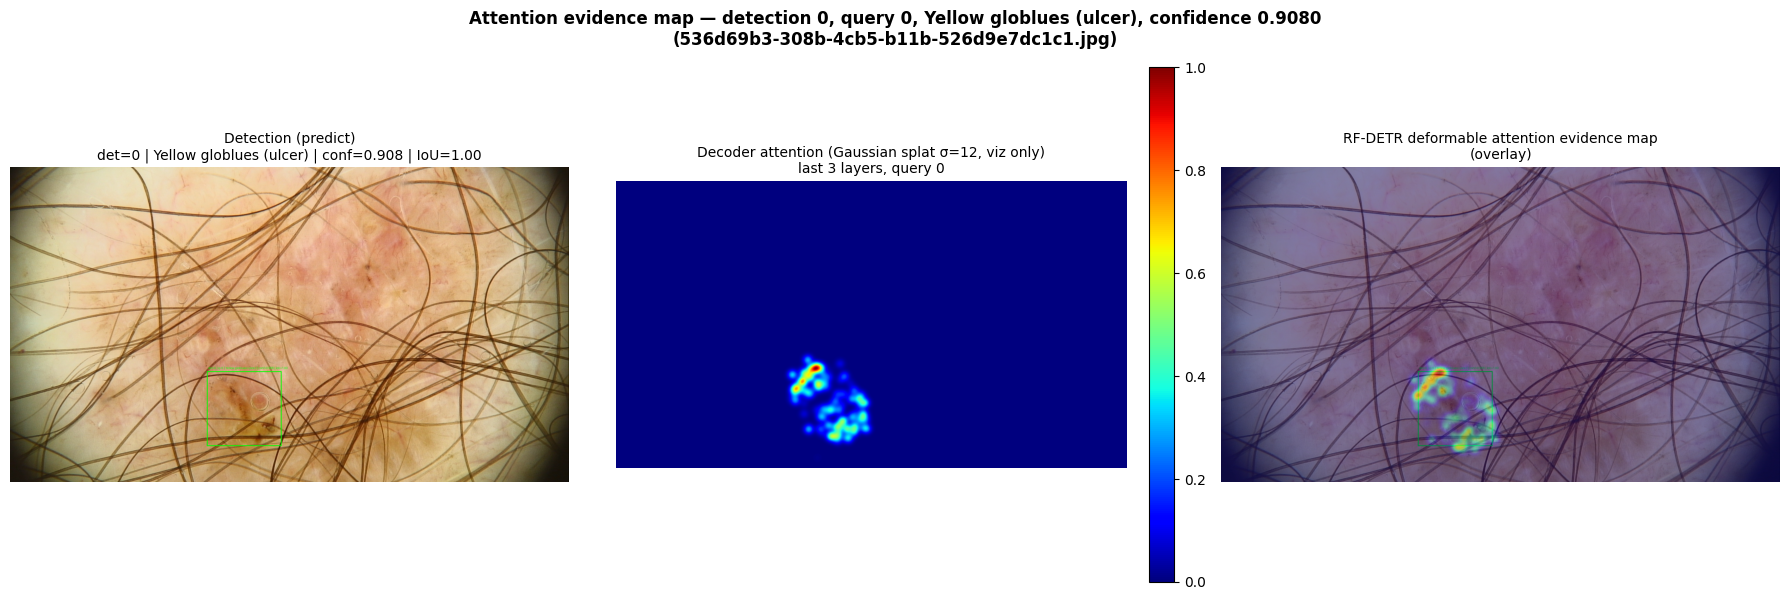

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(source_boxed)
axes[0].set_title(
    f'Detection (predict)\ndet={EXPLAIN_DET_INDEX} | {cname} | conf={score:.3f} | IoU={matched_iou:.2f}',
    fontsize=10,
)

im = axes[1].imshow(heat, cmap='jet', vmin=0, vmax=1)
axes[1].set_title(
    f'Decoder attention (Gaussian splat σ={GAUSSIAN_SPLAT_SIGMA:g}, viz only)\n'
    f'last {LAST_N_LAYERS} layers, query {query_id}',
    fontsize=10,
)
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(overlay)
axes[2].set_title('RF-DETR deformable attention evidence map\n(overlay)', fontsize=10)

for ax in axes:
    ax.axis('off')

plt.suptitle(
    f'Attention evidence map — detection {EXPLAIN_DET_INDEX}, query {query_id}, '
    f'{cname}, confidence {score:.4f}\n({Path(IMAGE_PATH).name})',
    fontsize=12,
    fontweight='bold',
)
plt.tight_layout()

fig_path = out_dir / f'{stem}_figure.png'
plt.savefig(str(fig_path), dpi=120, bbox_inches='tight')
print(f'✓ Saved figure: {fig_path}')
plt.show()

## Diagnostic: accepted query vs rejected low-probability slots

Obok głównej figury: **heatmapa dopasowanego (accepted) query** oraz **trzy małe heatmapy** dla slotów o **najniższym** `max(sigmoid(logits))` spośród query **nie** powiązanych z żadną detekcją z `predict()` — wyłącznie **kontrola negatywna**, nie część XAI per detekcja.

**Caption (defensive, for figures / methods):**

> Heatmaps of low-confidence query slots are shown only as a diagnostic sanity check. The quantitative XAI analysis is restricted to queries matched to final detections returned by the standard prediction pipeline.

**Metodologia:** główna analiza = finalne detekcje → dopasowane query → wyjaśnienie; ta sekcja = odrzucone sloty wyłącznie jako sanity check, bez mieszania z wynikami per-detection XAI.

In [ ]:
DISCLAIMER_DIAG = (
    'Heatmaps of low-confidence query slots are shown only as a diagnostic sanity check. '
    'The quantitative XAI analysis is restricted to queries matched to final detections returned '
    'by the standard prediction pipeline.'
)

if pred_detections is None or len(pred_detections) == 0:
    print('Skip diagnostic panel: no predict() detections.')
    _diag_ok = False
else:
    try:
        _ = outputs, recorder, matches, query_id, source
        _diag_ok = True
    except NameError:
        print(
            'Skip diagnostic panel: run the raw forward + heatmap cells first '
            '(outputs / recorder / matches / query_id).'
        )
        _diag_ok = False

if _diag_ok:
    matched_qs = {int(m['query_id']) for m in matches}
    rejected = pick_low_conf_rejected_queries(outputs, matched_qs, n=3)
    rp = outputs['pred_logits'][0].sigmoid()
    acc_maxp = float(rp[query_id].max().detach().cpu())

    hw = source.shape[:2]
    h_acc = gaussian_heatmap_for_query(
        recorder.records,
        query_id,
        hw,
        LAST_N_LAYERS,
        GAUSSIAN_SPLAT_SIGMA,
        POST_SPLAT_BLUR,
    )

    fig_d, axd = plt.subplots(1, 4, figsize=(17, 3.6), constrained_layout=False)
    axd[0].imshow(h_acc, cmap='jet', vmin=0, vmax=1)
    axd[0].set_title(
        f'Accepted (matched)\nq={query_id}\nmax cls prob={acc_maxp:.4f}',
        fontsize=8,
    )
    axd[0].axis('off')

    for j in range(3):
        ax = axd[j + 1]
        if j < len(rejected):
            rq, rmp = rejected[j]
            h_r = gaussian_heatmap_for_query(
                recorder.records,
                rq,
                hw,
                LAST_N_LAYERS,
                GAUSSIAN_SPLAT_SIGMA,
                POST_SPLAT_BLUR,
            )
            ax.imshow(h_r, cmap='jet', vmin=0, vmax=1)
            ax.set_title(
                f'Rejected (diagnostic)\nq={rq}\nmax cls prob={rmp:.4f}',
                fontsize=8,
            )
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')

    fig_d.suptitle(
        'Diagnostic only: matched query vs lowest-probability unmatched query slots',
        fontsize=11,
        y=1.02,
    )
    fig_d.text(
        0.5,
        0.02,
        DISCLAIMER_DIAG,
        ha='center',
        va='top',
        fontsize=8.5,
        wrap=True,
        transform=fig_d.transFigure,
    )
    plt.tight_layout(rect=[0, 0.14, 1, 0.92])

    out_d = Path(OUTPUT_DIR)
    stem_d = Path(IMAGE_PATH).stem if IMAGE_PATH else 'image'
    diag_path = out_d / f'{stem_d}_diagnostic_accepted_vs_rejected_queries.png'
    fig_d.savefig(str(diag_path), dpi=140, bbox_inches='tight')
    print(f'✓ Saved diagnostic figure: {diag_path}')
    plt.show()

## Batch: ta sama losowa próba (`N_RANDOM_DRAW`)

Dla indeksów z `RANDOM_IMAGE_INDICES` zapisuje mapy tylko tam, gdzie są detekcje (`predict`) i IoU dopasowania query ≥ `MIN_MATCH_IOU`.

In [19]:
all_images = manager.data['images']
# Ta sama próba co `RANDOM_IMAGE_INDICES` w komórce 1 — batch przetwarza tylko zdjęcia z detekcjami.
sample_idx = list(RANDOM_IMAGE_INDICES)

batch_results = []

for img_idx in sample_idx:
    img_path = Path(IMAGES_DIR) / Path(all_images[img_idx]['file_name']).name
    if not img_path.exists():
        print(f'  skip (not found): {img_path.name}')
        continue

    try:
        pil = Image.open(img_path).convert('RGB')
        det_check = model.predict(pil, threshold=THRESHOLD)
        if det_check is None or len(det_check) == 0:
            print(f'  skip (no detections): {img_path.name}')
            continue

        src, bat, tsz = preprocess_for_rfdetr(model, pil)
        with torch.no_grad():
            with DeformableAttentionRecorder(inner_model) as rec:
                outs = inner_model(bat)

        matched_rows = match_predict_detections_to_queries(
            det_check, outs, tsz, bat.device, min_match_iou=MIN_MATCH_IOU
        )
        m0 = matched_rows[0]
        if m0['matched_iou'] < MIN_MATCH_IOU:
            print(f'  skip (IoU {m0["matched_iou"]:.2f} < {MIN_MATCH_IOU}): {img_path.name}')
            continue

        qid = m0['query_id']
        cid = m0['class_id']
        scr = m0['confidence']
        bx = np.asarray(m0['box_xyxy'], dtype=np.float64)
        miou = m0['matched_iou']
        cnm = class_label_for_id(model, cid)

        _, hg = build_attention_heatmaps_sparse_and_gaussian(
            records=rec.records,
            query_id=qid,
            image_hw=src.shape[:2],
            use_last_n=LAST_N_LAYERS,
            gaussian_sigma=GAUSSIAN_SPLAT_SIGMA,
        )
        h = hg.astype(np.float32, copy=True)
        if POST_SPLAT_BLUR > 1:
            bk = POST_SPLAT_BLUR + (1 - POST_SPLAT_BLUR % 2)
            h = cv2.GaussianBlur(h, (bk, bk), 0)
            if h.max() > 0:
                h /= h.max()
        sb = draw_detection_box(
            src, bx, label=f'det=0 q={qid} {cnm} conf={scr:.2f} IoU={miou:.2f}'
        )
        ov = overlay_heatmap(sb, h, alpha=OVERLAY_ALPHA)

        op = out_dir / f'batch_{img_path.stem}_det0_q{qid}_overlay.png'
        Image.fromarray(ov).save(op)

        batch_results.append(
            dict(
                name=img_path.name,
                pil=pil,
                sb=sb,
                heat=h,
                ov=ov,
                qid=qid,
                cid=cid,
                cnm=cnm,
                scr=scr,
                miou=miou,
                bx=bx,
                op=op,
            )
        )
        print(f'  ✓ {img_path.name}  det=0 q={qid} {cnm} conf={scr:.3f} IoU={miou:.2f}')

    except Exception as e:
        import traceback

        print(f'  ✗ {img_path.name}: {e}')
        traceback.print_exc()

print(f'\nBatch done: {len(batch_results)}/10 images processed')

  skip (no detections): ee4aba4a-72d1-428d-a046-c5123ef729c6.jpg


  ✓ 536d69b3-308b-4cb5-b11b-526d9e7dc1c1.jpg  det=0 q=0 Yellow globlues (ulcer) conf=0.908 IoU=1.00
  ✓ 493115a5-9d36-4dc5-be5f-e602ce70d6bf.jpg  det=0 q=0 Yellow globlues (ulcer) conf=0.830 IoU=1.00
  ✓ b6b6e8af-be3e-464a-a046-17fe04ca7ff9.jpg  det=0 q=0 Yellow globlues (ulcer) conf=0.874 IoU=1.00
  skip (no detections): 33e8cefc-f7df-412c-a1a1-1cd619a9b9e7.jpg
  ✓ c093fcb2-d3f6-4987-8879-c55746ccf804.jpg  det=0 q=0 Yellow globlues (ulcer) conf=0.786 IoU=1.00
  ✓ eae54301-c864-4206-bd41-456ecd0647ac.jpg  det=0 q=0 Yellow globlues (ulcer) conf=0.906 IoU=1.00
  skip (no detections): 72573027-0213-43a9-aca5-37a0de45e728.jpg
  ✓ c6114f6a-ed61-4600-b7db-c0c2513f6e03.jpg  det=0 q=0 Yellow globlues (ulcer) conf=0.814 IoU=1.00
  skip (no detections): 4f01044f-2584-4c02-a586-2857a6bce518.jpg

Batch done: 6/10 images processed


✓ Saved batch figure: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/dermato_ai/rfdetr-xai/wyniki/rfdetr_xai_v3_attention/batch_attention_maps.png


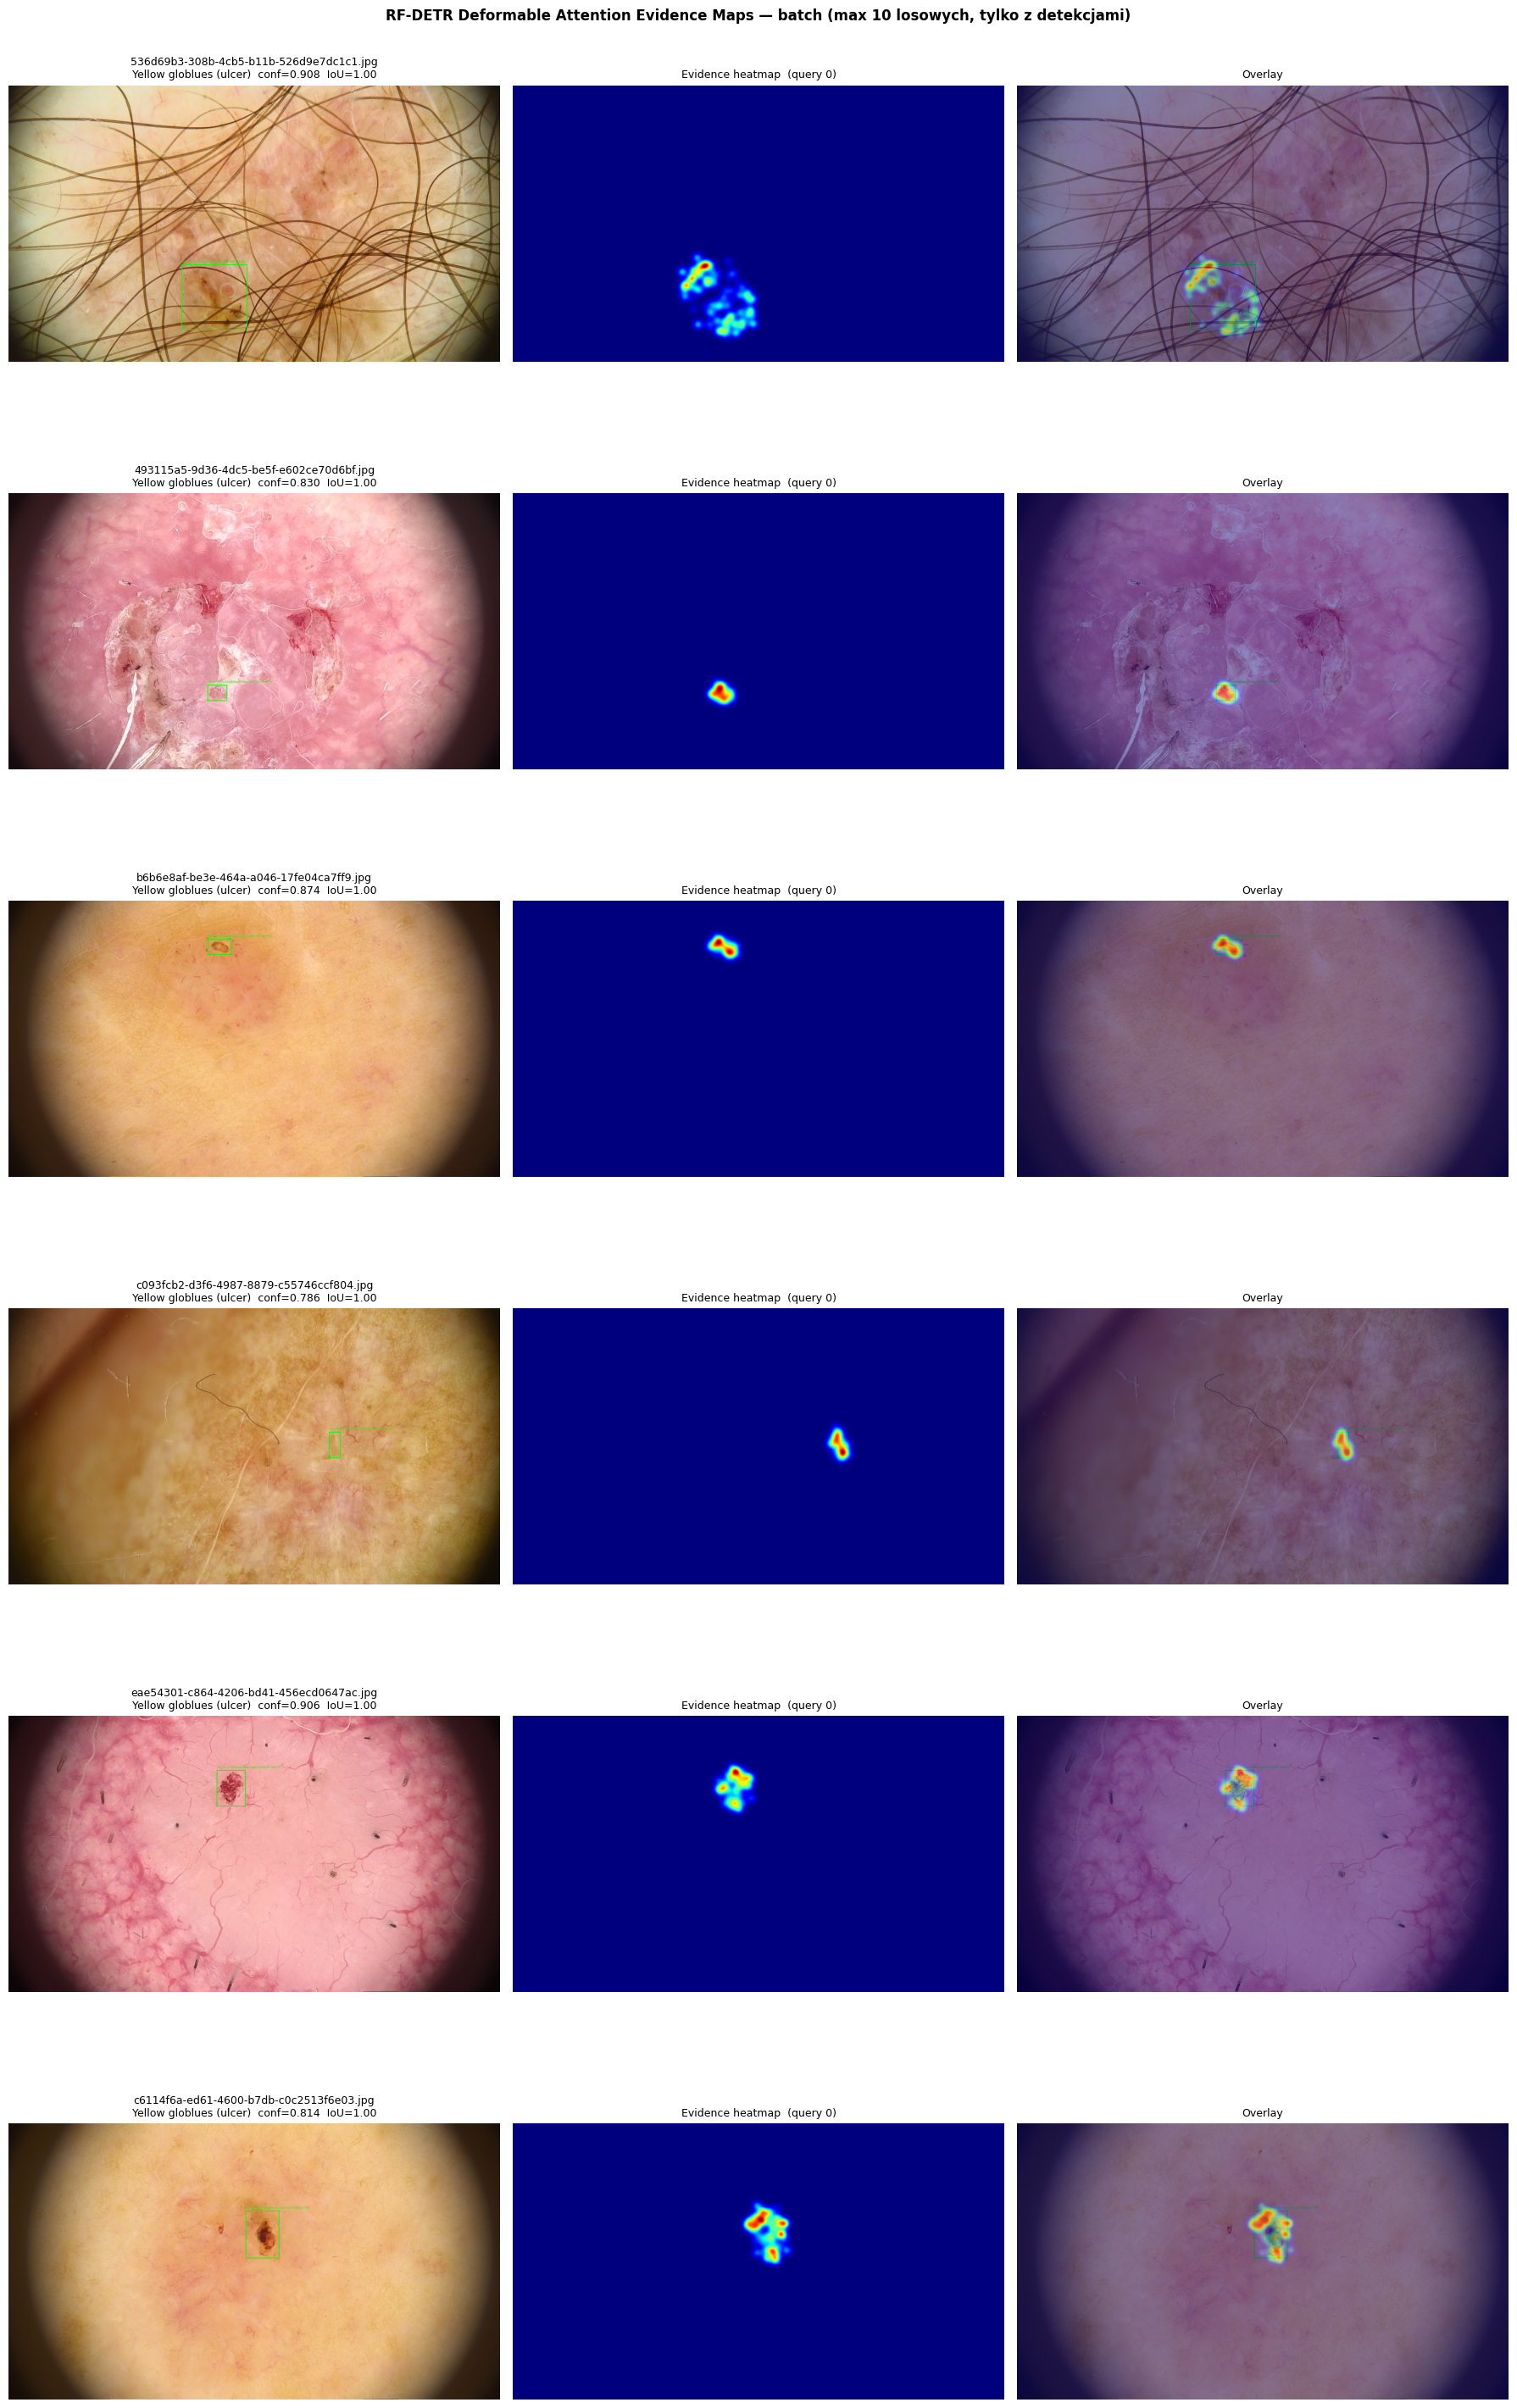

In [20]:
n = len(batch_results)
if n == 0:
    print('No batch results to display.')
else:
    fig, axes = plt.subplots(n, 3, figsize=(18, 5 * n))
    if n == 1:
        axes = axes.reshape(1, -1)

    for i, r in enumerate(batch_results):
        axes[i, 0].imshow(r['sb'])
        axes[i, 0].set_title(
            f"{r['name'][:40]}\n{r['cnm']}  conf={r['scr']:.3f}  IoU={r['miou']:.2f}",
            fontsize=9,
        )
        axes[i, 1].imshow(r['heat'], cmap='jet', vmin=0, vmax=1)
        axes[i, 1].set_title(f'Evidence heatmap  (query {r["qid"]})', fontsize=9)
        axes[i, 2].imshow(r['ov'])
        axes[i, 2].set_title('Overlay', fontsize=9)
        for ax in axes[i]:
            ax.axis('off')

    plt.suptitle(
        f'RF-DETR Deformable Attention Evidence Maps — batch (max {N_RANDOM_DRAW} losowych, tylko z detekcjami)',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    batch_fig = out_dir / 'batch_attention_maps.png'
    plt.savefig(str(batch_fig), dpi=100, bbox_inches='tight')
    print(f'\u2713 Saved batch figure: {batch_fig}')
    plt.show()